### Cluster Analysis
This Code is meant to build open the existing project created by my ENGO 537 Group. Specifically on the visualization aspect of the project by creating cluster analyses on the Banff Area

In [1]:
import pandas as pd

df = pd.read_csv('Data/Spatial Analysis.csv')

In [2]:
df.head()

,Longitude,Latitude,Encounter Type
0,-57.922166,0.006011,curious_risk
1,-82.515234,41.900301,curious_risk
2,-82.509150,41.901669,neutral_passive
3,-82.513520,41.906181,neutral_passive
4,-82.510085,41.906297,neutral_passive


In [3]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

# Actual polygon of Mount Revelstoke National Park
park_boundary = ox.geocode_to_gdf('Mount Revelstoke National Park')

# Convert original dataframe to a GeoDataFrame
gdf_all = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.Longitude, df.Latitude),
    crs="EPSG:4326"
)

# Clip the points to the Mount Revelstoke National Park boundary
gdf_points = gpd.clip(gdf_all, park_boundary)

print(f"Extracted {len(gdf_points)} points within Mount Revelstoke National Park.")

Extracted 276 points within Mount Revelstoke National Park.


In [4]:
gdf_points = gdf_points.to_crs("EPSG:3400")
gdf_points.head()

,Longitude,Latitude,Encounter Type,geometry
9738,-118.197180,51.005276,neutral_passive,POINT (275794.916 5653014.69)
9740,-118.186452,51.006168,aggressive,POINT (276551.352 5653081.212)
9742,-118.197391,51.006392,neutral_passive,POINT (275785.507 5653139.346)
9743,-118.189824,51.006681,neutral_passive,POINT (276317.412 5653148.453)
9748,-118.195370,51.007115,curious_risk,POINT (275930.684 5653213.538)


In [5]:
gdf_points["Lat"] = gdf_points.geometry.y
gdf_points["Lon"] = gdf_points.geometry.x
gdf_points.head()

,Longitude,Latitude,Encounter Type,geometry,Lat,Lon
9738,-118.197180,51.005276,neutral_passive,POINT (275794.916 5653014.69),5.653015e+06,275794.915969
9740,-118.186452,51.006168,aggressive,POINT (276551.352 5653081.212),5.653081e+06,276551.351501
9742,-118.197391,51.006392,neutral_passive,POINT (275785.507 5653139.346),5.653139e+06,275785.507312
9743,-118.189824,51.006681,neutral_passive,POINT (276317.412 5653148.453),5.653148e+06,276317.412326
9748,-118.195370,51.007115,curious_risk,POINT (275930.684 5653213.538),5.653214e+06,275930.683565


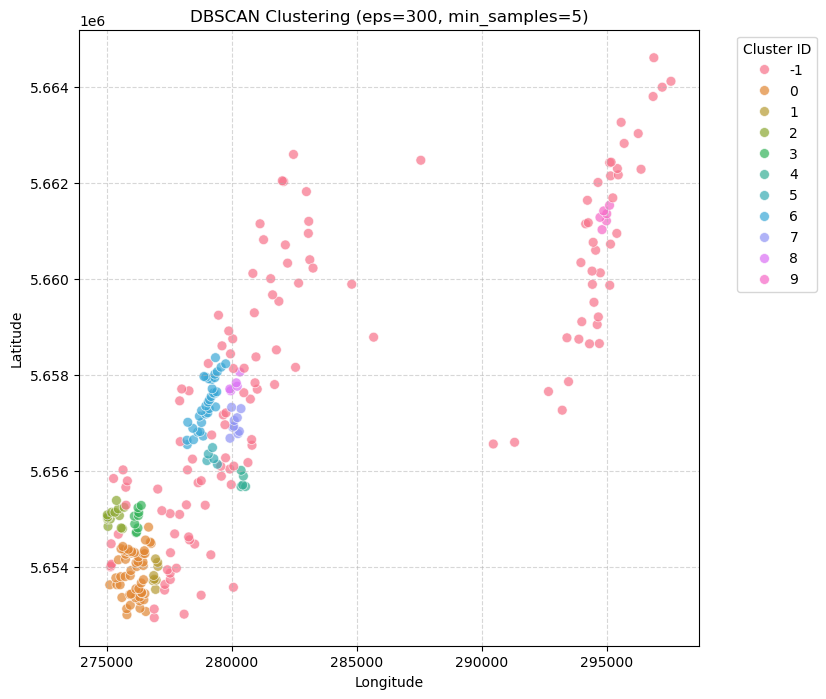

Number of clusters found: 10
Number of noise points (outliers): 131


In [6]:
import dbscanFunctions as userfunc

# Run DBSCAN clustering
clusters = userfunc.dbscan_plot(300, 5, gdf_points)


In [7]:
# Finding the Best Parameter Values
# Defining the sample range
min_samples_range = range(2, 20)
best_eps, best_min_samples, labels = userfunc.dbscan_best_parameters(gdf_points, 1500, 300, 200, min_samples_range)

Best eps:  1260.0
Best min_samples:  6


In [8]:
# Creating a Folim Map based on the best parameters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
map = userfunc.dbscan_folium(n_clusters, labels, gdf_points)

map

In [9]:
encounter = ['aggressive', 'curious_risk', 'neutral_passive']
cluster_label = [0, 1]
gdf_points['cluster'] = labels

userfunc.statistics(encounter, cluster_label, gdf_points)

Number of aggressive encounters in cluster 0: 36
Number of aggressive encounters in cluster 1: 2
Number of curious_risk encounters in cluster 0: 43
Number of curious_risk encounters in cluster 1: 0
Number of neutral_passive encounters in cluster 0: 148
Number of neutral_passive encounters in cluster 1: 39

Summary of counts:
('aggressive', 0): 36
('aggressive', 1): 2
('curious_risk', 0): 43
('curious_risk', 1): 0
('neutral_passive', 0): 148
('neutral_passive', 1): 39
Percentage aggressive encounters in cluster 0: 15.86%
Percentage aggressive encounters in cluster 1: 4.88%
Percentage curious_risk encounters in cluster 0: 18.94%
Percentage curious_risk encounters in cluster 1: 0.00%
Percentage neutral_passive encounters in cluster 0: 65.20%
Percentage neutral_passive encounters in cluster 1: 95.12%


## Performing the Same Analysis on the Banff Data to highlight the differences between the DataSets

In [10]:
# Actual polygon of Banff National Park
park_boundary = ox.geocode_to_gdf('Banff National Park')

# Convert original dataframe to a GeoDataFrame
gdf_all = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.Longitude, df.Latitude),
    crs="EPSG:4326"
)

# Clip the points to the Banff National Park boundary
gdf_points = gpd.clip(gdf_all, park_boundary)

print(f"Extracted {len(gdf_points)} points within Banff National Park.")

Extracted 22621 points within Banff National Park.


In [11]:
gdf_points = gdf_points.to_crs("EPSG:3400")
gdf_points.head()

,Longitude,Latitude,Encounter Type,geometry
9477,-115.439213,50.782022,aggressive,POINT (469049.027 5623426.022)
10091,-115.440742,51.076443,aggressive,POINT (469136.759 5656153.683)
9565,-115.475203,50.870046,neutral_passive,POINT (466575.742 5633226.029)
9573,-115.473446,50.873790,neutral_passive,POINT (466701.994 5633641.403)
10106,-115.458366,51.078772,aggressive,POINT (467904.234 5656420.109)


In [12]:
gdf_points["Lat"] = gdf_points.geometry.y
gdf_points["Lon"] = gdf_points.geometry.x
gdf_points.head()

,Longitude,Latitude,Encounter Type,geometry,Lat,Lon
9477,-115.439213,50.782022,aggressive,POINT (469049.027 5623426.022),5.623426e+06,469049.026880
10091,-115.440742,51.076443,aggressive,POINT (469136.759 5656153.683),5.656154e+06,469136.759047
9565,-115.475203,50.870046,neutral_passive,POINT (466575.742 5633226.029),5.633226e+06,466575.741974
9573,-115.473446,50.873790,neutral_passive,POINT (466701.994 5633641.403),5.633641e+06,466701.993773
10106,-115.458366,51.078772,aggressive,POINT (467904.234 5656420.109),5.656420e+06,467904.234209


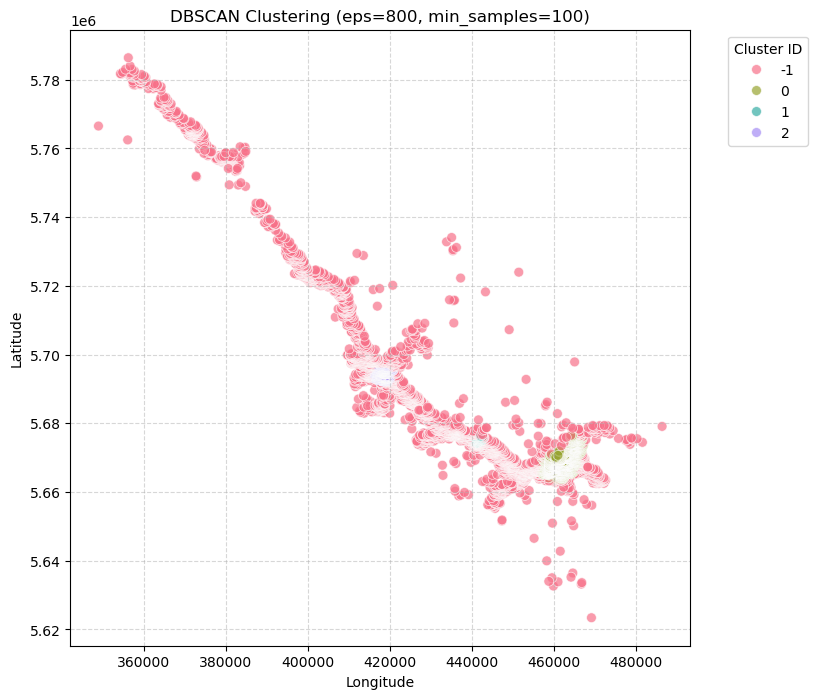

Number of clusters found: 3
Number of noise points (outliers): 4815


In [13]:
# Run DBSCAN clustering
clusters = userfunc.dbscan_plot(800, 100, gdf_points)

In [15]:
# Finding the Best Parameter Values
# Defining the sample range
min_samples_range = range(150, 200, 25)
best_eps, best_min_samples, labels = userfunc.dbscan_best_parameters(gdf_points, 4200, 2400, 600, min_samples_range)

Best eps:  2400.0
Best min_samples:  150


In [18]:
# Creating a Folim Map based on the best parameters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
map = userfunc.dbscan_folium(n_clusters, labels, gdf_points)

map

map.save("Banff_DBSCAN_Map.html")

In [17]:
encounter = ['aggressive', 'curious_risk', 'neutral_passive']
gdf_points['cluster'] = labels
cluster_label = gdf_points['cluster'].unique()

userfunc.statistics(encounter, cluster_label, gdf_points)

Number of aggressive encounters in cluster -1: 122
Number of aggressive encounters in cluster 0: 1209
Number of aggressive encounters in cluster 1: 19
Number of aggressive encounters in cluster 2: 133
Number of curious_risk encounters in cluster -1: 404
Number of curious_risk encounters in cluster 0: 2680
Number of curious_risk encounters in cluster 1: 105
Number of curious_risk encounters in cluster 2: 648
Number of neutral_passive encounters in cluster -1: 1034
Number of neutral_passive encounters in cluster 0: 14380
Number of neutral_passive encounters in cluster 1: 345
Number of neutral_passive encounters in cluster 2: 1542

Summary of counts:
('aggressive', np.int64(-1)): 122
('aggressive', np.int64(0)): 1209
('aggressive', np.int64(1)): 19
('aggressive', np.int64(2)): 133
('curious_risk', np.int64(-1)): 404
('curious_risk', np.int64(0)): 2680
('curious_risk', np.int64(1)): 105
('curious_risk', np.int64(2)): 648
('neutral_passive', np.int64(-1)): 1034
('neutral_passive', np.int64(